# **Applies transfer learning with Transformers in a hierarchical setup. Fine-tunes BERT/DistilBERT for Level-1 superclass prediction and Level-2 leaf classification, with typical training configs. Outputs accuracy/macro-F1, full reports, confusion matrices, and saves the fine-tuned model and label mappings.**

In [ ]:
!pip install transformers scikit-learn

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizerFast, BertForSequenceClassification, get_scheduler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_20newsgroups
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm

In [ ]:
# Load full 20 Newsgroups data
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers','footers','quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers','footers','quotes'))

# Convert to DataFrame
df_train = pd.DataFrame({
    'text_final': newsgroups_train.data,
    'target_name': [newsgroups_train.target_names[i] for i in newsgroups_train.target]
})

df_test = pd.DataFrame({
    'text_final': newsgroups_test.data,
    'target_name': [newsgroups_test.target_names[i] for i in newsgroups_test.target]
})

# Combine train and test for remapping
df = pd.concat([df_train, df_test]).reset_index(drop=True)
print(df.shape)
df.head()

(18846, 2)


,text_final,target_name
0,I was wondering if anyone out there could enli...,rec.autos
1,A fair number of brave souls who upgraded thei...,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the gh...",comp.sys.mac.hardware
3,\nDo you have Weitek's address/phone number? ...,comp.graphics
4,"From article <C5owCB.n3p@world.std.com>, by to...",sci.space


In [ ]:
label_mapping = {
    "rec.sport.hockey": "sports",
    "rec.sport.baseball": "sports",
    "rec.autos": "autos",
    "rec.motorcycles": "autos",
    "comp.graphics": "computers",
    "comp.sys.ibm.pc.hardware": "computers",
    "comp.sys.mac.hardware": "computers",
    "comp.windows.x": "computers",
    "comp.os.ms-windows.misc": "computers",
    "sci.crypt": "science",
    "sci.med": "science",
    "sci.space": "science",
    "sci.electronics": "science",
    "soc.religion.christian": "religion",
    "talk.religion.misc": "religion",
    "alt.atheism": "religion",
    "talk.politics.mideast": "politics",
    "talk.politics.guns": "politics",
    "talk.politics.misc": "politics",
    "misc.forsale": "sales"
}

df["new_category"] = df["target_name"].map(label_mapping)
print(df["new_category"].value_counts())

new_category
computers    4891
science      3952
politics     2625
religion     2424
sports       1993
autos        1986
sales         975
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()
df["new_category_encoded"] = le.fit_transform(df["new_category"])

label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_map)

{'autos': np.int64(0), 'computers': np.int64(1), 'politics': np.int64(2), 'religion': np.int64(3), 'sales': np.int64(4), 'science': np.int64(5), 'sports': np.int64(6)}


In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["new_category_encoded"]
)

print(train_df.shape, test_df.shape)

(15076, 4) (3770, 4)


In [ ]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    train_df["text_final"].tolist(),
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
)

test_encodings = tokenizer(
    test_df["text_final"].tolist(),
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
)

train_labels = torch.tensor(train_df["new_category_encoded"].values)
test_labels = torch.tensor(test_df["new_category_encoded"].values)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = NewsDataset(train_encodings, train_labels)
test_dataset = NewsDataset(test_encodings, test_labels)

In [ ]:
num_labels = len(df["new_category"].unique())

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

num_epochs = 2
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
total_steps = num_epochs * len(train_loader)

scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [ ]:
progress_bar = tqdm(range(total_steps))

model.train()
for epoch in range(num_epochs):
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)
    print(f"Epoch {epoch+1} complete.")

  0%|          | 0/1886 [00:00<?, ?it/s]

Epoch 1 complete.
Epoch 2 complete.


In [ ]:
model.eval()
all_preds = []
all_labels = []

test_loader = DataLoader(test_dataset, batch_size=16)

for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
    logits = outputs.logits
    preds = torch.argmax(logits, dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(batch["labels"].cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print("Test Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Test Accuracy: 0.8681697612732096

Classification Report:
              precision    recall  f1-score   support

       autos       0.90      0.84      0.87       397
   computers       0.91      0.91      0.91       978
    politics       0.80      0.85      0.83       525
    religion       0.89      0.84      0.86       485
       sales       0.90      0.88      0.89       195
     science       0.79      0.85      0.82       791
      sports       0.94      0.89      0.92       399

    accuracy                           0.87      3770
   macro avg       0.88      0.86      0.87      3770
weighted avg       0.87      0.87      0.87      3770



<Figure size 600x500 with 0 Axes>

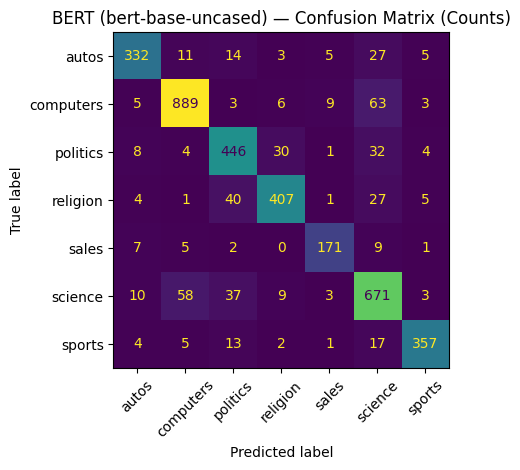

<Figure size 600x500 with 0 Axes>

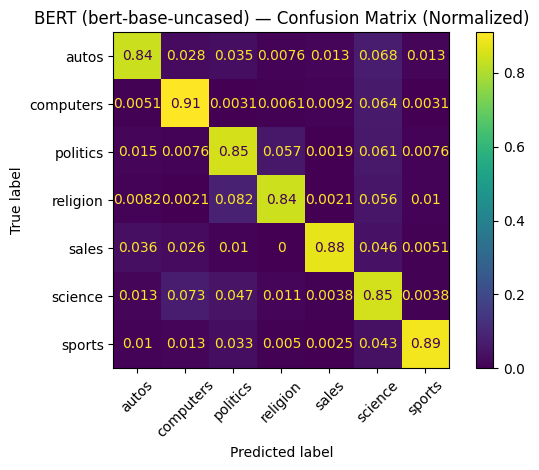

In [ ]:
#Confusion Matrices for BERT
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

labels = np.arange(len(le.classes_))
display_labels = le.classes_

# Raw counts
cm = confusion_matrix(all_labels, all_preds, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
plt.figure(figsize=(6,5))
disp.plot(values_format="d", xticks_rotation=45, colorbar=False)
plt.title("BERT (bert-base-uncased) — Confusion Matrix (Counts)")
plt.tight_layout()
plt.show()

# Row-normalized
cm_norm = confusion_matrix(all_labels, all_preds, labels=labels, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=display_labels)
plt.figure(figsize=(6,5))
disp.plot(xticks_rotation=45, colorbar=True)
plt.title("BERT (bert-base-uncased) — Confusion Matrix (Normalized)")
plt.tight_layout()
plt.show()


Saved: bert_classification_report.csv


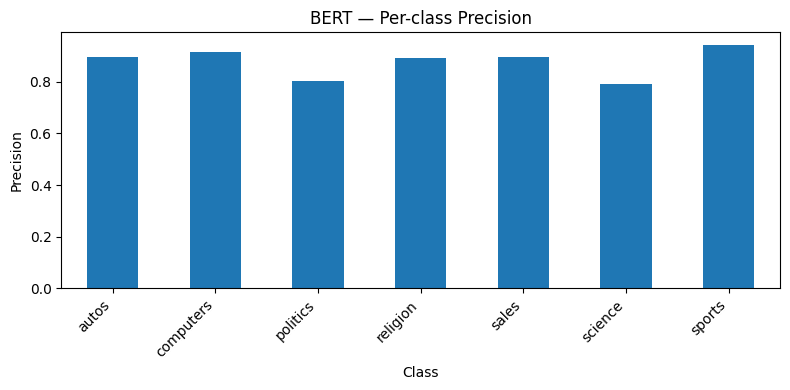

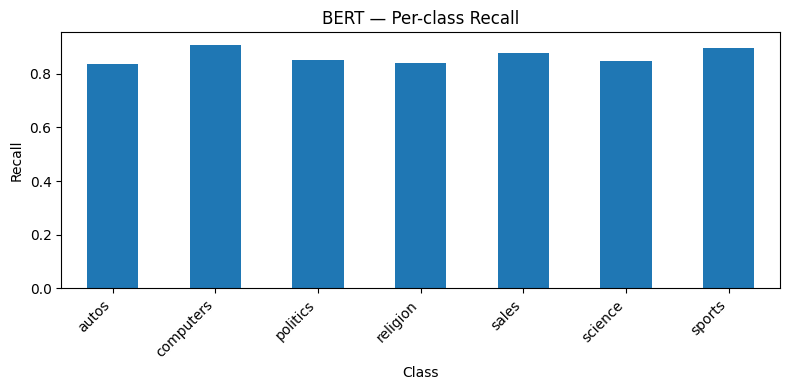

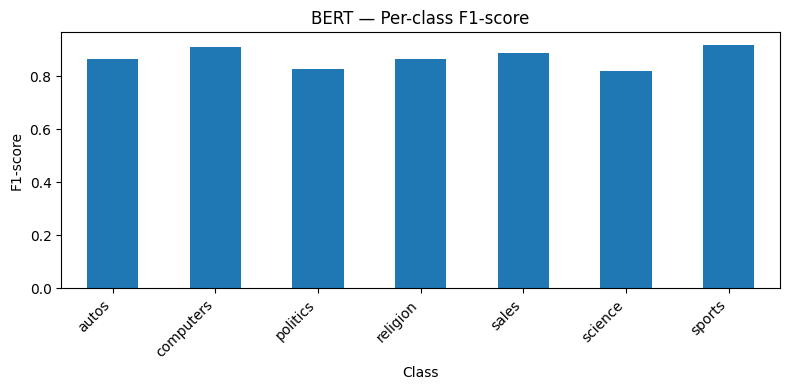

In [ ]:
# Save tidy classification report + bar plots
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Make a tidy DataFrame from the classification report
rep = classification_report(all_labels, all_preds, target_names=le.classes_, output_dict=True, digits=4)
rep_df = pd.DataFrame(rep).T

# Save to CSV
rep_df.to_csv("bert_classification_report.csv", index=True)
print("Saved: bert_classification_report.csv")

# Plot per-class Precision / Recall / F1
per_class = rep_df.loc[le.classes_, ["precision","recall","f1-score"]]

# Precision
ax = per_class["precision"].plot(kind="bar", figsize=(8,4))
ax.set_title("BERT — Per-class Precision")
ax.set_xlabel("Class")
ax.set_ylabel("Precision")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Recall
ax = per_class["recall"].plot(kind="bar", figsize=(8,4))
ax.set_title("BERT — Per-class Recall")
ax.set_xlabel("Class")
ax.set_ylabel("Recall")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# F1-score
ax = per_class["f1-score"].plot(kind="bar", figsize=(8,4))
ax.set_title("BERT — Per-class F1-score")
ax.set_xlabel("Class")
ax.set_ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
all_preds = []
all_labels = []

for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
    logits = outputs.logits
    preds = torch.argmax(logits, dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(batch["labels"].cpu().numpy())


In [ ]:
y_test = np.array(all_labels)

In [ ]:
y_pred = np.array(all_preds)

In [ ]:
import numpy as np

# Convert lists to arrays
y_test = np.array(all_labels)
y_pred = np.array(all_preds)


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    output_dict=True
)

import pandas as pd

report_df = pd.DataFrame(report).transpose()
report_df = report_df.loc[le.classes_]
print(report_df)


           precision    recall  f1-score  support
autos       0.897297  0.836272  0.865711    397.0
computers   0.913669  0.908998  0.911328    978.0
politics    0.803604  0.849524  0.825926    525.0
religion    0.890591  0.839175  0.864119    485.0
sales       0.895288  0.876923  0.886010    195.0
science     0.793144  0.848293  0.819792    791.0
sports      0.944444  0.894737  0.918919    399.0


           precision    recall  f1-score  support
autos       0.897297  0.836272  0.865711    397.0
computers   0.913669  0.908998  0.911328    978.0
politics    0.803604  0.849524  0.825926    525.0
religion    0.890591  0.839175  0.864119    485.0
sales       0.895288  0.876923  0.886010    195.0
science     0.793144  0.848293  0.819792    791.0
sports      0.944444  0.894737  0.918919    399.0


/tmp/ipython-input-3107372576.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


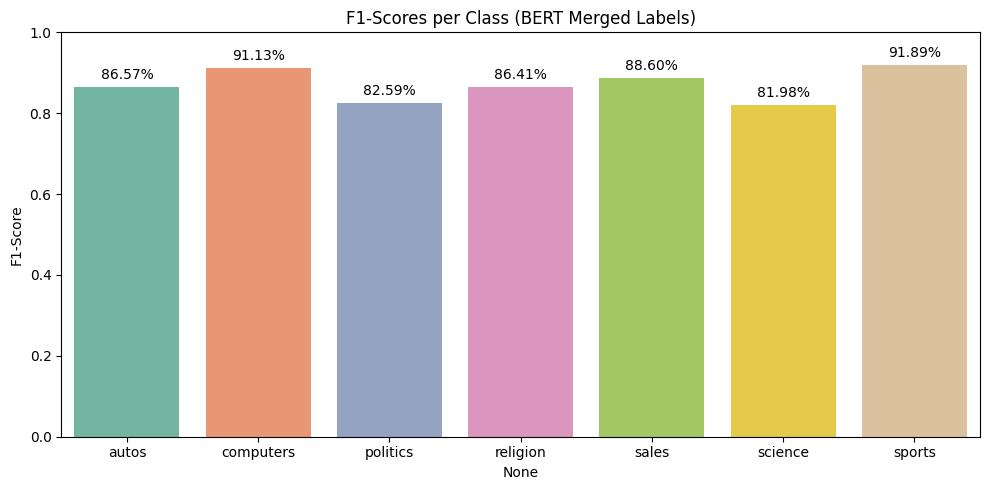

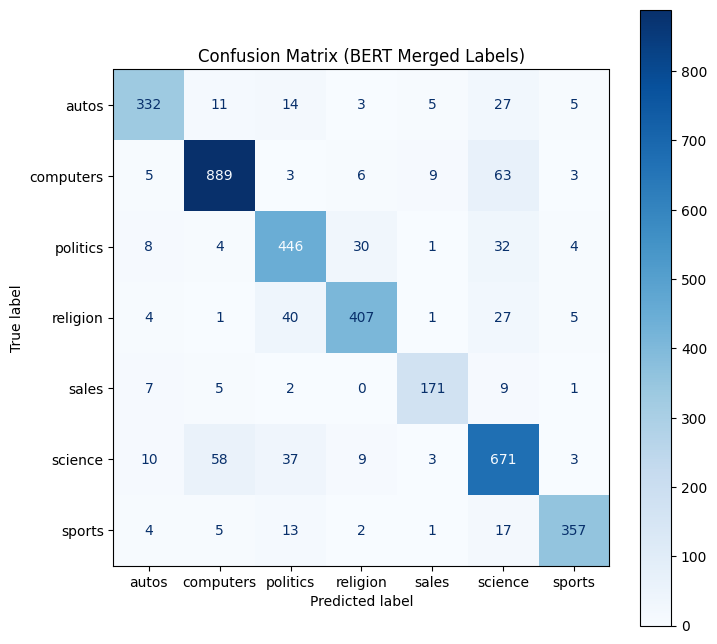

In [ ]:
import numpy as np

# Create arrays from predictions
y_test = np.array(all_labels)
y_pred = np.array(all_preds)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    output_dict=True
)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()
report_df = report_df.loc[le.classes_]
print(report_df)

# Plot F1-scores
plt.figure(figsize=(10,5))
sns.barplot(
    x=report_df.index,
    y=report_df["f1-score"],
    palette="Set2"
)
plt.ylim(0, 1)
plt.title("F1-Scores per Class (BERT Merged Labels)")
plt.ylabel("F1-Score")
for i, v in enumerate(report_df["f1-score"]):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center')
plt.tight_layout()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix (BERT Merged Labels)")
plt.show()


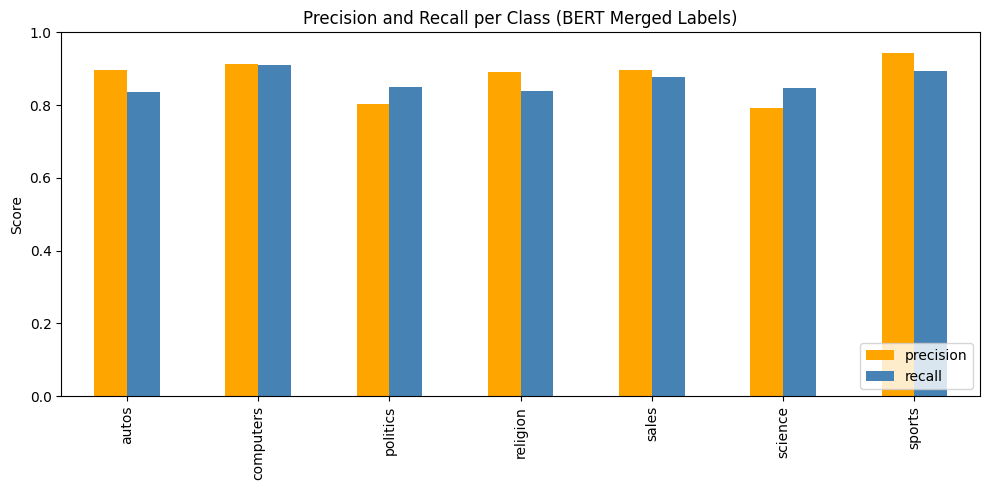

In [ ]:
report_df[["precision", "recall"]].plot(
    kind='bar',
    figsize=(10,5),
    ylim=(0,1),
    color=['orange', 'steelblue']
)

plt.title("Precision and Recall per Class (BERT Merged Labels)")
plt.ylabel("Score")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


/tmp/ipython-input-2834341709.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


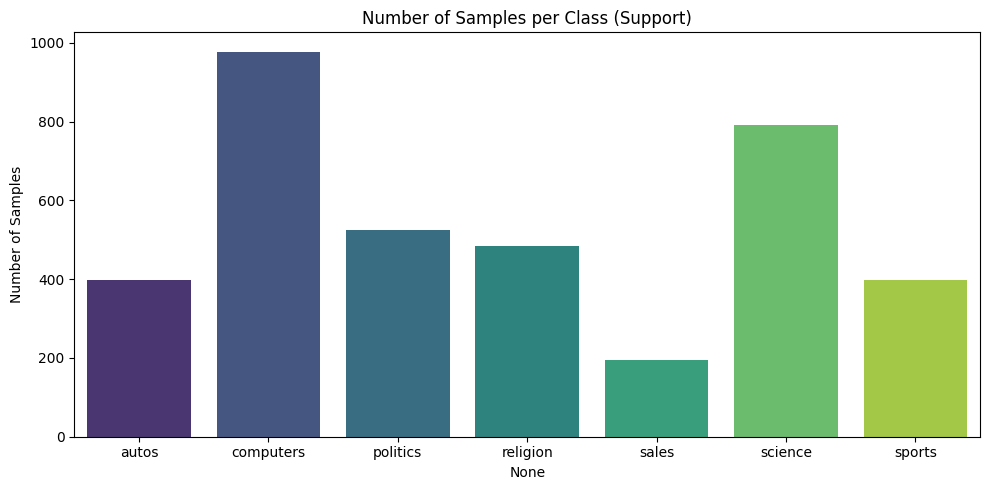

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=report_df.index,
    y=report_df["support"],
    palette="viridis"
)
plt.title("Number of Samples per Class (Support)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()


In [ ]:
# Map each high-level label to its original classes
group_mapping = {
    "sports": [
        "rec.sport.hockey",
        "rec.sport.baseball"
    ],
    "autos": [
        "rec.autos",
        "rec.motorcycles"
    ],
    "computers": [
        "comp.graphics",
        "comp.sys.ibm.pc.hardware",
        "comp.sys.mac.hardware",
        "comp.windows.x",
        "comp.os.ms-windows.misc"
    ],
    "science": [
        "sci.crypt",
        "sci.med",
        "sci.space",
        "sci.electronics"
    ],
    "religion": [
        "soc.religion.christian",
        "talk.religion.misc",
        "alt.atheism"
    ],
    "politics": [
        "talk.politics.mideast",
        "talk.politics.guns",
        "talk.politics.misc"
    ],
    "sales": [
        "misc.forsale"
    ]
}

In [ ]:
from sklearn.preprocessing import LabelEncoder

# To store trained sub-models
fine_tuned_models = {}
fine_label_encoders = {}

In [ ]:
for group, fine_classes in group_mapping.items():
    print(f"Training fine-grained model for group: {group}")

    # Filter original dataframe for this group
    df_group = df[df["new_category"] == group]

    # Skip groups with only one class (like sales)
    if len(fine_classes) == 1:
        print(f"Skipping {group} because it has only one class.")
        continue

    # Encode fine-level labels
    le_fine = LabelEncoder()
    df_group["fine_label_encoded"] = le_fine.fit_transform(df_group["target_name"])

    # Split into train/test
    train_df_group, test_df_group = train_test_split(
        df_group,
        test_size=0.2,
        random_state=42,
        stratify=df_group["fine_label_encoded"]
    )

    # Tokenize
    train_encodings_group = tokenizer(
        train_df_group["text_final"].tolist(),
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    test_encodings_group = tokenizer(
        test_df_group["text_final"].tolist(),
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    train_labels_group = torch.tensor(train_df_group["fine_label_encoded"].values)
    test_labels_group = torch.tensor(test_df_group["fine_label_encoded"].values)

    # Create dataset
    train_dataset_group = NewsDataset(train_encodings_group, train_labels_group)
    test_dataset_group = NewsDataset(test_encodings_group, test_labels_group)

    # Load new BERT model
    num_fine_labels = len(le_fine.classes_)

    model_group = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=num_fine_labels
    )

    model_group.to(device)

    optimizer_group = AdamW(model_group.parameters(), lr=2e-5)

    num_epochs = 2
    train_loader_group = DataLoader(train_dataset_group, batch_size=16, shuffle=True)
    total_steps = num_epochs * len(train_loader_group)

    scheduler_group = get_scheduler(
        "linear",
        optimizer=optimizer_group,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    # Train
    progress_bar = tqdm(range(total_steps))

    model_group.train()
    for epoch in range(num_epochs):
        for batch in train_loader_group:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model_group(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer_group.step()
            scheduler_group.step()
            optimizer_group.zero_grad()
            progress_bar.update(1)
        print(f"Fine model for {group} — Epoch {epoch+1} complete.")

    # Evaluate
    model_group.eval()
    all_preds_group = []
    all_labels_group = []

    test_loader_group = DataLoader(test_dataset_group, batch_size=16)

    for batch in test_loader_group:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model_group(**batch)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        all_preds_group.extend(preds.cpu().numpy())
        all_labels_group.extend(batch["labels"].cpu().numpy())

    acc_group = accuracy_score(all_labels_group, all_preds_group)
    print(f"Fine model accuracy for group {group}: {acc_group:.4f}")

    print(classification_report(
        all_labels_group,
        all_preds_group,
        target_names=le_fine.classes_
    ))

    # Save this model and label encoder
    fine_tuned_models[group] = model_group
    fine_label_encoders[group] = le_fine

/tmp/ipython-input-285887441.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group["fine_label_encoded"] = le_fine.fit_transform(df_group["target_name"])


Training fine-grained model for group: sports


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/200 [00:00<?, ?it/s]

Fine model for sports — Epoch 1 complete.
Fine model for sports — Epoch 2 complete.
Fine model accuracy for group sports: 0.9323
                    precision    recall  f1-score   support

rec.sport.baseball       0.93      0.94      0.93       199
  rec.sport.hockey       0.94      0.93      0.93       200

          accuracy                           0.93       399
         macro avg       0.93      0.93      0.93       399
      weighted avg       0.93      0.93      0.93       399

Training fine-grained model for group: autos


...

  0%|          | 0/244 [00:00<?, ?it/s]

Fine model for religion — Epoch 1 complete.
Fine model for religion — Epoch 2 complete.
Fine model accuracy for group religion: 0.6454
                        precision    recall  f1-score   support

           alt.atheism       0.60      0.76      0.67       160
soc.religion.christian       0.69      0.84      0.76       199
    talk.religion.misc       0.58      0.20      0.30       126

              accuracy                           0.65       485
             macro avg       0.63      0.60      0.58       485
          weighted avg       0.63      0.65      0.61       485

Training fine-grained model for group: politics


/tmp/ipython-input-285887441.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group["fine_label_encoded"] = le_fine.fit_transform(df_group["target_name"])
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/264 [00:00<?, ?it/s]

Fine model for politics — Epoch 1 complete.
Fine model for politics — Epoch 2 complete.
Fine model accuracy for group politics: 0.8381
                       precision    recall  f1-score   support

   talk.politics.guns       0.84      0.83      0.84       182
talk.politics.mideast       0.91      0.90      0.91       188
   talk.politics.misc       0.75      0.77      0.76       155

             accuracy                           0.84       525
            macro avg       0.83      0.83      0.83       525
         weighted avg       0.84      0.84      0.84       525

Training fine-grained model for group: sales
Skipping sales because it has only one class.


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrices(y_true, y_pred, label_encoder, group_name, model_name="BERT Fine"):
    """Plot raw count & normalized confusion matrices for one fine-grained model."""
    labels = np.arange(len(label_encoder.classes_))
    display_labels = label_encoder.classes_

    # Raw counts
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    plt.figure(figsize=(6,5))
    disp.plot(values_format="d", xticks_rotation=45, cmap="Blues", colorbar=False)
    plt.title(f"{model_name} — Confusion Matrix (Counts) | Group: {group_name}")
    plt.tight_layout()
    plt.show()

    # Row-normalized
    cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=display_labels)
    plt.figure(figsize=(6,5))
    disp.plot(xticks_rotation=45, cmap="Blues", colorbar=True)
    plt.title(f"{model_name} — Confusion Matrix (Normalized) | Group: {group_name}")
    plt.tight_layout()
    plt.show()

In [ ]:
print(classification_report(
    all_labels_group,
    all_preds_group,
    target_names=le_fine.classes_
))

                       precision    recall  f1-score   support

   talk.politics.guns       0.84      0.83      0.84       182
talk.politics.mideast       0.91      0.90      0.91       188
   talk.politics.misc       0.75      0.77      0.76       155

             accuracy                           0.84       525
            macro avg       0.83      0.83      0.83       525
         weighted avg       0.84      0.84      0.84       525




 Evaluating fine group: sports


/tmp/ipython-input-3246107668.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group["fine_label_encoded"] = le_fine.fit_transform(df_group["target_name"])


                    precision    recall  f1-score   support

rec.sport.baseball     0.9257    0.9397    0.9327       199
  rec.sport.hockey     0.9391    0.9250    0.9320       200

          accuracy                         0.9323       399
         macro avg     0.9324    0.9323    0.9323       399
      weighted avg     0.9324    0.9323    0.9323       399



<Figure size 600x500 with 0 Axes>

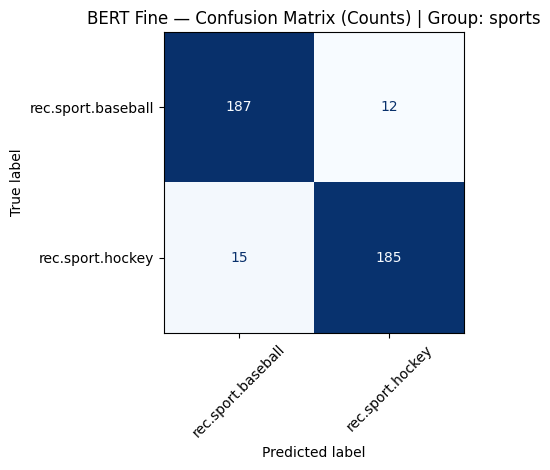

<Figure size 600x500 with 0 Axes>

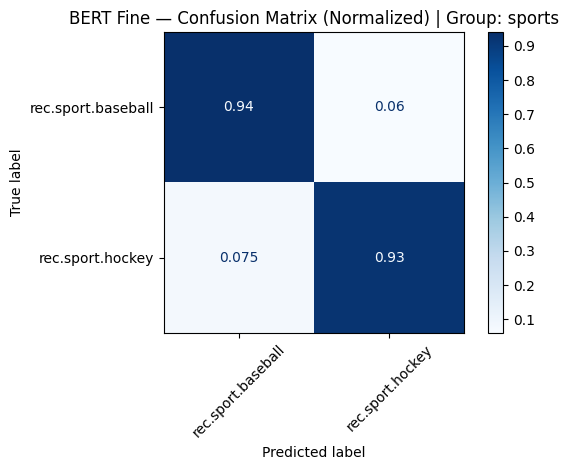


 Evaluating fine group: computers


/tmp/ipython-input-3246107668.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group["fine_label_encoded"] = le_fine.fit_transform(df_group["target_name"])


                          precision    recall  f1-score   support

           comp.graphics     0.7538    0.7538    0.7538       195
 comp.os.ms-windows.misc     0.7389    0.6751    0.7056       197
comp.sys.ibm.pc.hardware     0.6939    0.6939    0.6939       196
   comp.sys.mac.hardware     0.7136    0.7876    0.7488       193
          comp.windows.x     0.8667    0.8535    0.8601       198

                accuracy                         0.7528       979
               macro avg     0.7534    0.7528    0.7524       979
            weighted avg     0.7537    0.7528    0.7526       979



<Figure size 600x500 with 0 Axes>

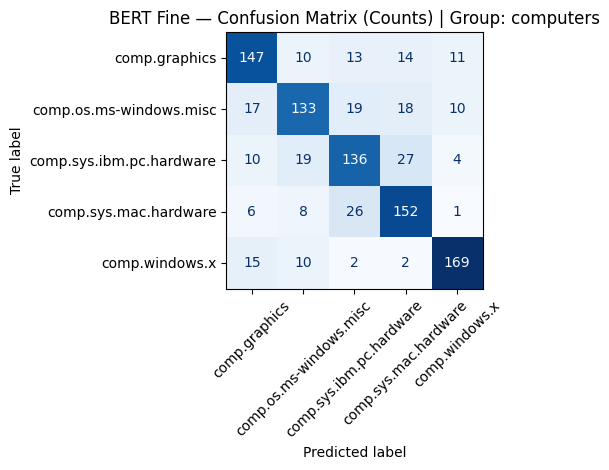

<Figure size 600x500 with 0 Axes>

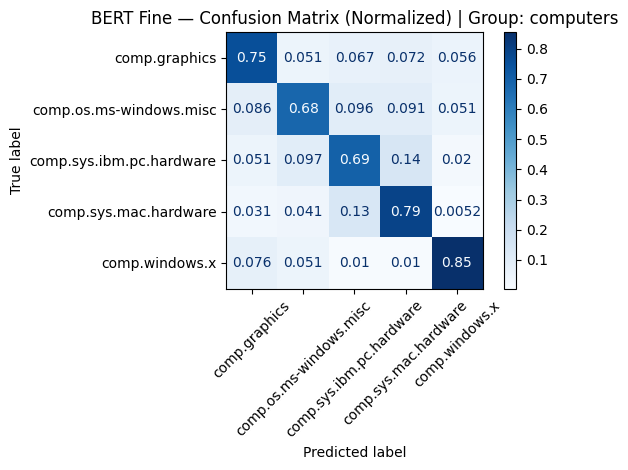


 Evaluating fine group: science


/tmp/ipython-input-3246107668.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group["fine_label_encoded"] = le_fine.fit_transform(df_group["target_name"])


                 precision    recall  f1-score   support

      sci.crypt     0.8018    0.9192    0.8565       198
sci.electronics     0.9302    0.8122    0.8672       197
        sci.med     0.9113    0.9343    0.9227       198
      sci.space     0.9101    0.8687    0.8889       198

       accuracy                         0.8837       791
      macro avg     0.8883    0.8836    0.8838       791
   weighted avg     0.8883    0.8837    0.8838       791



<Figure size 600x500 with 0 Axes>

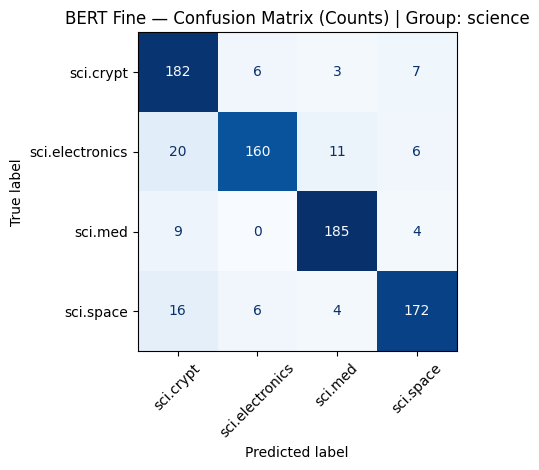

<Figure size 600x500 with 0 Axes>

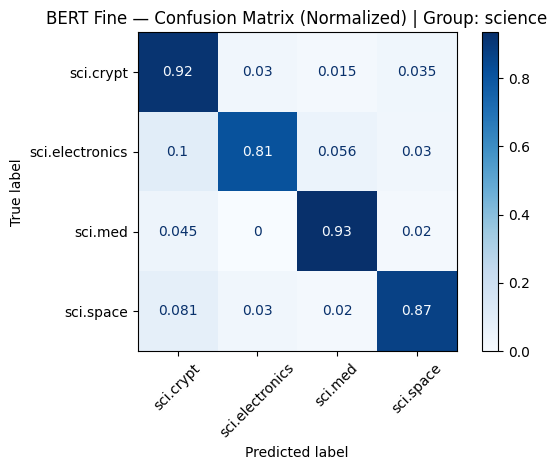

In [ ]:
#Evaluate specific fine groups
target_groups = ["sports", "computers", "science"]  # choose whichever groups you want

for group in target_groups:
    print(f"\n Evaluating fine group: {group}")

    df_group = df[df["new_category"] == group]

    le_fine = LabelEncoder()
    df_group["fine_label_encoded"] = le_fine.fit_transform(df_group["target_name"])

    # Split
    train_df_group, test_df_group = train_test_split(
        df_group,
        test_size=0.2,
        random_state=42,
        stratify=df_group["fine_label_encoded"]
    )

    # Tokenize
    test_encodings_group = tokenizer(
        test_df_group["text_final"].tolist(),
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )
    test_labels_group = torch.tensor(test_df_group["fine_label_encoded"].values)
    test_dataset_group = NewsDataset(test_encodings_group, test_labels_group)
    test_loader_group = DataLoader(test_dataset_group, batch_size=16)

    # Load trained model + encoder from your dictionary
    model_group = fine_tuned_models[group]
    le_fine = fine_label_encoders[group]

    # Evaluate
    model_group.eval()
    all_preds_group, all_labels_group = [], []
    for batch in test_loader_group:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model_group(**batch)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds_group.extend(preds.cpu().numpy())
        all_labels_group.extend(batch["labels"].cpu().numpy())

    # Report
    print(classification_report(
        all_labels_group,
        all_preds_group,
        target_names=le_fine.classes_,
        digits=4
    ))

    # Confusion matrices
    plot_confusion_matrices(all_labels_group, all_preds_group, le_fine, group_name=group, model_name="BERT Fine")


In [ ]:
# Encode a single text for BERT
text = "The Hockey News is a Canadian-based ice hockey magazine. The Hockey News was founded in 1947 by Ken McKenzie and Will Cote and has since become the most recognized hockey publication in North America.."

inputs = tokenizer(
    text,
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
).to(device)

# Predict high-level label
model.eval()
with torch.no_grad():
    outputs = model(**inputs)
logits = outputs.logits
pred_class_idx = torch.argmax(logits, dim=1).item()
pred_group_label = le.inverse_transform([pred_class_idx])[0]

print("High-level prediction:", pred_group_label)

High-level prediction: sports


In [ ]:
if pred_group_label not in fine_tuned_models:
    print("Fine prediction:", pred_group_label)
else:
    fine_model = fine_tuned_models[pred_group_label]
    fine_encoder = fine_label_encoders[pred_group_label]

    fine_model.eval()
    with torch.no_grad():
        fine_outputs = fine_model(**inputs)
    fine_logits = fine_outputs.logits
    fine_pred_idx = torch.argmax(fine_logits, dim=1).item()
    fine_pred_label = fine_encoder.inverse_transform([fine_pred_idx])[0]

    print("Fine-grained prediction:", fine_pred_label)

Fine-grained prediction: rec.sport.hockey


In [ ]:
import os
import pickle

#Define your save folder
base_path = "/content/bert_models"

# Create the folder if it doesn't exist
os.makedirs(base_path, exist_ok=True)

#Save Level-1 model
model.save_pretrained(os.path.join(base_path, "bert_level1_model"))
tokenizer.save_pretrained(os.path.join(base_path, "bert_level1_model"))

with open(os.path.join(base_path, "level1_encoder.pkl"), "wb") as f:
    pickle.dump(le, f)

print("Level-1 model saved.")

#Save Level-2 models
for group, fine_model in fine_tuned_models.items():
    fine_model_path = os.path.join(base_path, f"bert_fine_{group}")
    fine_model.save_pretrained(fine_model_path)

    fine_encoder = fine_label_encoders[group]
    with open(os.path.join(base_path, f"fine_encoder_{group}.pkl"), "wb") as f:
        pickle.dump(fine_encoder, f)

    print(f"Saved fine model for {group}")


✅ Level-1 model saved.
✅ Saved fine model for sports
✅ Saved fine model for autos
✅ Saved fine model for computers
✅ Saved fine model for science
✅ Saved fine model for religion
✅ Saved fine model for politics


In [ ]:
!zip -r bert_models.zip bert_models

  adding: bert_models/ (stored 0%)
  adding: bert_models/bert_fine_politics/ (stored 0%)
  adding: bert_models/bert_fine_politics/model.safetensors (deflated 7%)
  adding: bert_models/bert_fine_politics/config.json (deflated 51%)
  adding: bert_models/level1_encoder.pkl (deflated 20%)
  adding: bert_models/fine_encoder_sports.pkl (deflated 18%)
  adding: bert_models/bert_fine_autos/ (stored 0%)
  adding: bert_models/bert_fine_autos/model.safetensors (deflated 7%)
  adding: bert_models/bert_fine_autos/config.json (deflated 49%)
  adding: bert_models/bert_level1_model/ (stored 0%)
  adding: bert_models/bert_level1_model/special_tokens_map.json (deflated 42%)
  adding: bert_models/bert_level1_model/tokenizer.json (deflated 71%)
  adding: bert_models/bert_level1_model/model.safetensors (deflated 7%)
  adding: bert_models/bert_level1_model/config.json (deflated 55%)
  adding: bert_models/bert_level1_model/vocab.txt (deflated 53%)
  adding: bert_models/bert_level1_model/tokenizer_config.json

In [ ]:
from google.colab import files
files.download("bert_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Run model
fine_model.eval()
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
pred_class_idx = torch.argmax(logits, dim=1).item()
pred_group_label = le.inverse_transform([pred_class_idx])[0]

print("Level-1 prediction:", pred_group_label)

Level-1 prediction: sports


In [ ]:
text = "The patient was diagnosed with a rare neurological condition requiring treatment."
# Tokenize
inputs = tokenizer(
    text,
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
).to(device)
# Level-1 prediction
model.eval()
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
pred_class_idx = torch.argmax(logits, dim=1).item()
pred_group_label = le.inverse_transform([pred_class_idx])[0]

print("Level-1 prediction:", pred_group_label)

Level-1 prediction: science


In [ ]:
# Level-2 prediction
if pred_group_label not in fine_tuned_models:
    final_label = pred_group_label
    print("Final prediction:", final_label)
else:
    fine_model = fine_tuned_models[pred_group_label]
    fine_encoder = fine_label_encoders[pred_group_label]

    fine_model.eval()
    with torch.no_grad():
        fine_outputs = fine_model(**inputs)
    fine_logits = fine_outputs.logits
    fine_pred_idx = torch.argmax(fine_logits, dim=1).item()
    fine_pred_label = fine_encoder.inverse_transform([fine_pred_idx])[0]

    print("Final fine-grained prediction:", fine_pred_label)

Final fine-grained prediction: sci.med
